# Sprint 2: Model Building & Evaluation



# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Models

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi']    = 100

In [5]:
df = pd.read_csv("/Users/rezwanshehik/Downloads/sprint_1_e.csv")

In [6]:
df

,job_title,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,education_required,years_experience,...,job_description_length,benefits_score,application_duration,posting_month,posting_year,posting_day,day_of_week,days_to_apply,skills_count,salary_usd
0,0.003399,-2.261256,-0.445200,0.573224,-0.181799,1.234367,0.516249,-1.206612,-0.441457,-0.762152,...,0.192669,-0.411952,1.695907,0.419900,-0.566700,0.366307,0.505220,1.695907,0.007951,96731
1,1.575214,0.505698,0.450725,-1.072690,1.494300,-1.216598,1.377205,-1.206612,0.452030,-0.218426,...,-0.393901,-0.826906,0.773265,1.848779,-0.566700,1.162463,0.005991,0.773265,-1.215304,75146
2,0.258288,0.505698,-1.341125,-0.866951,-0.477582,0.008885,0.478816,-1.206612,0.452030,-1.124635,...,-0.270321,1.524501,-1.129683,-1.008979,1.764601,1.276200,0.005991,-1.129683,1.231207,39309
3,0.555658,0.505698,0.450725,1.327601,-0.280393,1.234367,-0.120110,0.019516,-0.441457,-0.218426,...,0.328433,-1.449337,-0.668363,1.563003,-0.566700,0.366307,-0.992468,-0.668363,1.231207,83948
4,-0.718787,0.505698,1.346650,-0.866951,1.494300,0.008885,0.141921,-1.206612,-1.334944,1.956474,...,0.841899,0.210480,-0.783693,-0.723203,1.764601,0.934990,-1.491698,-0.783693,0.007951,135830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,0.343250,0.505698,0.450725,1.327601,-0.625473,-1.216598,-0.756469,1.245644,-1.334944,0.325299,...,1.400619,-1.656814,1.234586,0.134124,-0.566700,-0.316112,0.005991,1.234586,0.007951,83404
14996,-0.931194,0.505698,1.346650,-0.866951,-0.477582,0.008885,-0.943633,-1.206612,-1.334944,1.412749,...,1.689553,0.348798,0.369609,-1.294755,1.764601,-0.884794,-0.493239,0.369609,1.231207,165635
14997,-0.633824,0.505698,0.450725,1.327601,-0.280393,0.008885,-1.505126,-1.206612,1.345517,0.325299,...,-0.728089,-0.411952,-0.899023,0.705676,-0.566700,-0.884794,0.005991,-0.899023,0.007951,73042
14998,-0.931194,0.505698,-1.341125,-0.866951,-0.329690,-1.216598,0.965444,0.019516,1.345517,-0.943393,...,0.570371,-0.757747,-0.553032,-0.437428,1.764601,-0.429848,1.004450,-0.553032,1.231207,33117


In [7]:
X_train = pd.read_csv("/Users/rezwanshehik/Downloads/X_train_final.csv")
X_test  = pd.read_csv("/Users/rezwanshehik/Downloads/X_test_final.csv")
y_train = pd.read_csv("/Users/rezwanshehik/Downloads/y_train.csv").squeeze()
y_test  = pd.read_csv("/Users/rezwanshehik/Downloads/y_test.csv").squeeze()

In [8]:
print(f" Sprint 1 data loaded!")
print(f"   X_train : {X_train.shape}")
print(f"   X_test  : {X_test.shape}")
print(f"   y_train : {y_train.shape}")
print(f"   y_test  : {y_test.shape}")

 Sprint 1 data loaded!
   X_train : (12000, 20)
   X_test  : (3000, 20)
   y_train : (12000,)
   y_test  : (3000,)


# Step 1: Baseline Model — Linear Regression

#### A baseline model is the simplest possible model we train first.
#### Its score tells us the minimum performance bar — every other model must beat this.
#### For regression → we use Linear Regression as baseline.

In [9]:
# Helper function to evaluate any model
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    # Predictions
    y_train_pred = model.predict(X_tr)
    y_test_pred  = model.predict(X_te)

    # Training metrics
    train_mae  = mean_absolute_error(y_tr, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_tr, y_train_pred))
    train_r2   = r2_score(y_tr, y_train_pred)

    # Testing metrics
    test_mae   = mean_absolute_error(y_te, y_test_pred)
    test_rmse  = np.sqrt(mean_squared_error(y_te, y_test_pred))
    test_r2    = r2_score(y_te, y_test_pred)

    # Overfitting gap
    r2_gap = train_r2 - test_r2
    status = " Overfit" if r2_gap > 0.1 else "Good"

    return {
        'Model'       : name,
        'Train MAE'   : round(train_mae,  2),
        'Test MAE'    : round(test_mae,   2),
        'Train RMSE'  : round(train_rmse, 2),
        'Test RMSE'   : round(test_rmse,  2),
        'Train R²'    : round(train_r2,   4),
        'Test R²'     : round(test_r2,    4),
        'R² Gap'      : round(r2_gap,     4),
        'Overfitting?': status
    }

print(" evaluate_model() helper function defined!")

 evaluate_model() helper function defined!


# STEP 1: Baseline — Linear Regression

In [10]:
lr = LinearRegression()
lr.fit(X_train, y_train)

baseline = evaluate_model('Linear Regression', lr, X_train, y_train, X_test, y_test)


In [11]:
print(f"  Train R²   : {baseline['Train R²']}")
print(f"  Test  R²   : {baseline['Test R²']}")
print(f"  Train RMSE : ${baseline['Train RMSE']:,.0f}")
print(f"  Test  RMSE : ${baseline['Test RMSE']:,.0f}")
print(f"  Test  MAE  : ${baseline['Test MAE']:,.0f}")
print(f"  Overfitting: {baseline['Overfitting?']}")

  Train R²   : 0.6252
  Test  R²   : 0.6274
  Train RMSE : $36,869
  Test  RMSE : $36,862
  Test  MAE  : $27,397
  Overfitting: Good


In [12]:
print(f" Baseline R² = {baseline['Test R²']} → all other models must beat this!")

 Baseline R² = 0.6274 → all other models must beat this!


# Step 2: Train Multiple Models

### Train all 4 models

# 1. Linear Regression (Baseline)

In [13]:
results = []

lr = LinearRegression()
lr.fit(X_train, y_train)
results.append(evaluate_model('Linear Regression', lr, X_train, y_train, X_test, y_test))

In [14]:
lr

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#  2. Decision Tree

In [15]:


dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
results.append(evaluate_model('Decision Tree', dt, X_train, y_train, X_test, y_test))

In [16]:
dt

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

# 3. Random Forest

In [17]:


rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
results.append(evaluate_model('Random Forest', rf, X_train, y_train, X_test, y_test))

In [18]:
rf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

# 4. Gradient Boosting

In [19]:


gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
results.append(evaluate_model('Gradient Boosting', gb, X_train, y_train, X_test, y_test))

In [20]:
gb

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

# Step 3: Model Evaluation

## 📌 Step 3: Model Evaluation
> We use 3 metrics to measure how good each model is:

| Metric | Full Name | What it means | Best value |
|--------|-----------|---------------|------------|
| **MAE** | Mean Absolute Error | Average dollar error in predictions | Lower is better |
| **RMSE** | Root Mean Squared Error | Penalises large errors more heavily | Lower is better |
| **R²** | R-squared | % of salary variation model explains | Closer to 1.0 is better |

In [21]:
# ── STEP 3: Evaluation — show metrics ────────────────
results_df = pd.DataFrame(results)
print("=" * 90)
print("  MODEL EVALUATION RESULTS")
print("=" * 90)
print(results_df[['Model','Train R²','Test R²','Train RMSE','Test RMSE','Test MAE','Overfitting?']].to_string(index=False))
print("=" * 90)

  MODEL EVALUATION RESULTS
            Model  Train R²  Test R²  Train RMSE  Test RMSE  Test MAE Overfitting?
Linear Regression    0.6252   0.6274    36868.99   36862.33  27397.03         Good
    Decision Tree    1.0000   0.7662        0.00   29202.56  19786.94      Overfit
    Random Forest    0.9825   0.8796     7971.58   20959.24  15000.83      Overfit
Gradient Boosting    0.8822   0.8791    20671.53   20998.37  15083.31         Good


# Plot 1: R² Score comparison (Train vs Test) 

/var/folders/vb/40q2b_4d7sdc3b0tbjnfx6z00000gn/T/ipykernel_3444/3963679745.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(models, rotation=12, ha='right', fontsize=9)


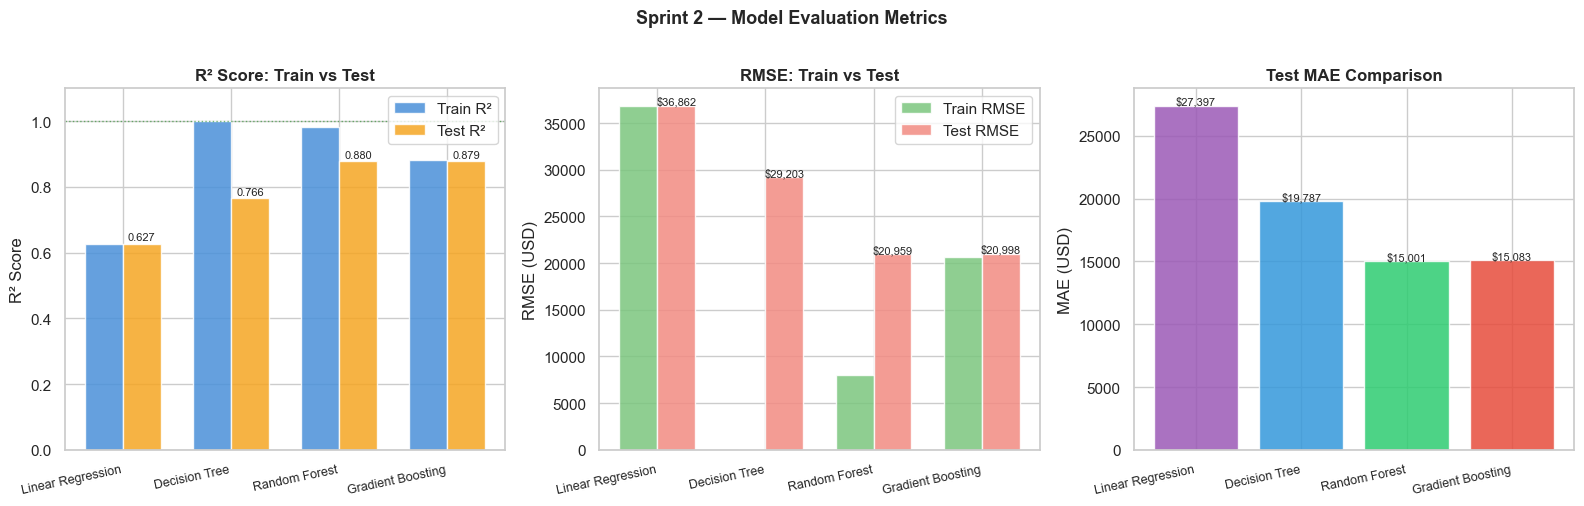

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models     = results_df['Model']
x          = np.arange(len(models))
width      = 0.35
colors_tr  = ['#4A90D9','#4A90D9','#4A90D9','#4A90D9']
colors_te  = ['#F5A623','#F5A623','#F5A623','#F5A623']


# R² Plot
bars1 = axes[0].bar(x - width/2, results_df['Train R²'], width, label='Train R²', color='#4A90D9', alpha=0.85)
bars2 = axes[0].bar(x + width/2, results_df['Test R²'],  width, label='Test R²',  color='#F5A623', alpha=0.85)
axes[0].set_title('R² Score: Train vs Test', fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(models, rotation=12, ha='right', fontsize=9)
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].axhline(1.0, color='green', linestyle=':', linewidth=1, alpha=0.5)
for b in bars2:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                 f"{b.get_height():.3f}", ha='center', fontsize=8)


# RMSE Plot
bars3 = axes[1].bar(x - width/2, results_df['Train RMSE'], width, label='Train RMSE', color='#7BC67E', alpha=0.85)
bars4 = axes[1].bar(x + width/2, results_df['Test RMSE'],  width, label='Test RMSE',  color='#F28B82', alpha=0.85)
axes[1].set_title('RMSE: Train vs Test', fontweight='bold')
axes[1].set_xticks(x); axes[1].set_xticklabels(models, rotation=12, ha='right', fontsize=9)
axes[1].set_ylabel('RMSE (USD)')
axes[1].legend()
for b in bars4:
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+100,
                 f"${b.get_height():,.0f}", ha='center', fontsize=8)


# MAE Plot
axes[2].bar(models, results_df['Test MAE'], color=['#9B59B6','#3498DB','#2ECC71','#E74C3C'], alpha=0.85)
axes[2].set_title('Test MAE Comparison', fontweight='bold')
axes[2].set_xticklabels(models, rotation=12, ha='right', fontsize=9)
axes[2].set_ylabel('MAE (USD)')
for i, v in enumerate(results_df['Test MAE']):
    axes[2].text(i, v+100, f"${v:,.0f}", ha='center', fontsize=8)

plt.suptitle('Sprint 2 — Model Evaluation Metrics', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

##  Step 4: Overfitting & Underfitting Check
> **Overfitting** → Model performs very well on training data but poorly on test data  
> **Underfitting** → Model performs poorly on both training and test data  
> **Good fit** → Similar performance on both — this is what we want

# STEP 4: Overfitting check

In [23]:
print(f"{'Model':<22} {'Train R²':>9} {'Test R²':>9} {'Gap':>8} {'Status':>15}")

for r in results:
    gap = r['Train R²'] - r['Test R²']
    if gap > 0.15:
        status = ">>>  Overfitting"
    elif r['Test R²'] < 0.5:
        status = " Underfitting"
    else:
        status = " Good fit"
    print(f"{r['Model']:<22} {r['Train R²']:>9.4f} {r['Test R²']:>9.4f} {gap:>8.4f} {status:>15}")

Model                   Train R²   Test R²      Gap          Status
Linear Regression         0.6252    0.6274  -0.0022        Good fit
Decision Tree             1.0000    0.7662   0.2338 >>>  Overfitting
Random Forest             0.9825    0.8796   0.1029        Good fit
Gradient Boosting         0.8822    0.8791   0.0031        Good fit


### "Rule: R² Gap > 0.15 → Overfitting | Test R² < 0.5 → Underfitting

## Actual vs Predicted plot for best model

In [24]:
best_model = rf   # we will confirm after comparison table
y_pred_best = best_model.predict(X_test)

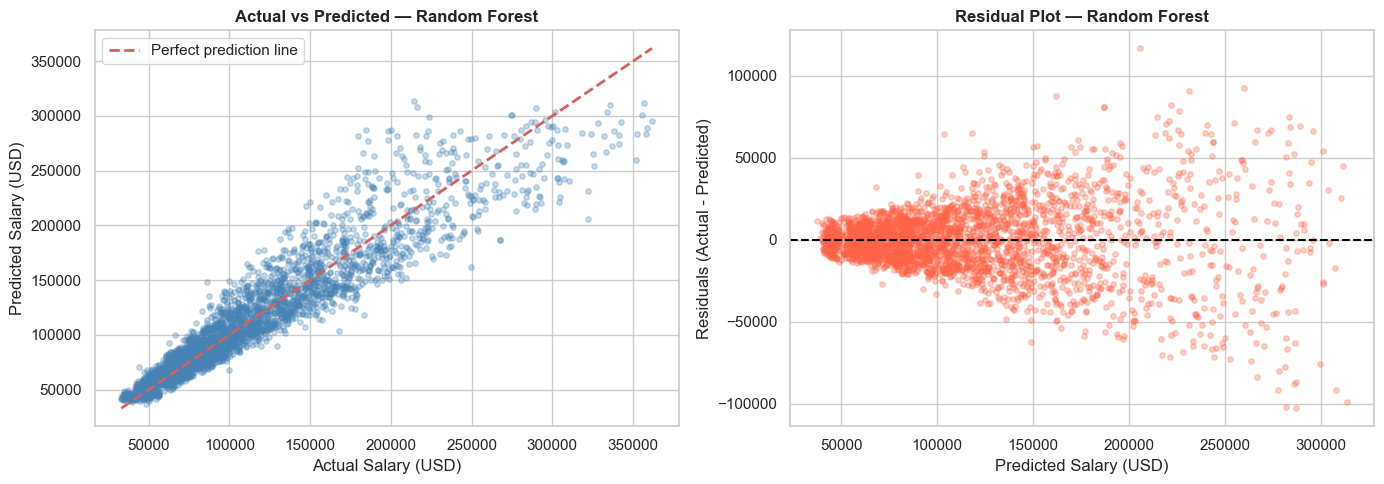

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted scatter
axes[0].scatter(y_test, y_pred_best, alpha=0.3, color='steelblue', s=15)
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect prediction line')
axes[0].set_title('Actual vs Predicted — Random Forest', fontweight='bold')
axes[0].set_xlabel('Actual Salary (USD)')
axes[0].set_ylabel('Predicted Salary (USD)')
axes[0].legend()

# Residuals plot
residuals = y_test.values - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.3, color='tomato', s=15)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual Plot — Random Forest', fontweight='bold')
axes[1].set_xlabel('Predicted Salary (USD)')
axes[1].set_ylabel('Residuals (Actual - Predicted)')

plt.tight_layout()
plt.show()

## Step 5: Model Comparison Table & Best Model Selection

### STEP 5: Final comparison table

In [26]:
comparison_df = pd.DataFrame(results)[
    ['Model','Train R²','Test R²','Train RMSE','Test RMSE','Test MAE','R² Gap','Overfitting?']
]

In [27]:
comparison_df

,Model,Train R²,Test R²,Train RMSE,Test RMSE,Test MAE,R² Gap,Overfitting?
0,Linear Regression,0.6252,0.6274,36868.99,36862.33,27397.03,-0.0022,Good
1,Decision Tree,1.0000,0.7662,0.00,29202.56,19786.94,0.2338,Overfit
2,Random Forest,0.9825,0.8796,7971.58,20959.24,15000.83,0.1029,Overfit
3,Gradient Boosting,0.8822,0.8791,20671.53,20998.37,15083.31,0.0031,Good


In [28]:
results

[{'Model': 'Linear Regression',
  'Train MAE': 27261.81,
  'Test MAE': 27397.03,
  'Train RMSE': np.float64(36868.99),
  'Test RMSE': np.float64(36862.33),
  'Train R²': 0.6252,
  'Test R²': 0.6274,
  'R² Gap': -0.0022,
  'Overfitting?': 'Good'},
 {'Model': 'Decision Tree',
  'Train MAE': 0.0,
  'Test MAE': 19786.94,
  'Train RMSE': np.float64(0.0),
  'Test RMSE': np.float64(29202.56),
  'Train R²': 1.0,
  'Test R²': 0.7662,
  'R² Gap': 0.2338,
  'Overfitting?': ' Overfit'},
 {'Model': 'Random Forest',
  'Train MAE': 5566.34,
  'Test MAE': 15000.83,
  'Train RMSE': np.float64(7971.58),
  'Test RMSE': np.float64(20959.24),
  'Train R²': 0.9825,
  'Test R²': 0.8796,
  'R² Gap': 0.1029,
  'Overfitting?': ' Overfit'},
 {'Model': 'Gradient Boosting',
  'Train MAE': 14707.03,
  'Test MAE': 15083.31,
  'Train RMSE': np.float64(20671.53),
  'Test RMSE': np.float64(20998.37),
  'Train R²': 0.8822,
  'Test R²': 0.8791,
  'R² Gap': 0.0031,
  'Overfitting?': 'Good'}]

In [29]:
# print(f"\n Best Model : {best_row['Model']}")
# print(f"   Test R²   : {best_row['Test R²']}")
# print(f"   Test RMSE : ${best_row['Test RMSE']:,.0f}")
# print(f"   Test MAE  : ${best_row['Test MAE']:,.0f}")

NameError: name 'best_row' is not defined

# Feature Importance (Random Forest)

In [30]:
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=True)

In [31]:
feat_imp

posting_year              0.001367
skills_count              0.003233
remote_ratio              0.003414
education_required        0.003924
employment_type           0.004337
day_of_week               0.006174
application_duration      0.006526
days_to_apply             0.006868
posting_month             0.008110
industry                  0.008523
job_title                 0.009703
posting_day               0.010587
benefits_score            0.012063
job_description_length    0.013653
employee_residence        0.017081
salary_currency           0.026852
company_size              0.049577
company_location          0.200507
experience_level          0.289944
years_experience          0.317557
dtype: float64

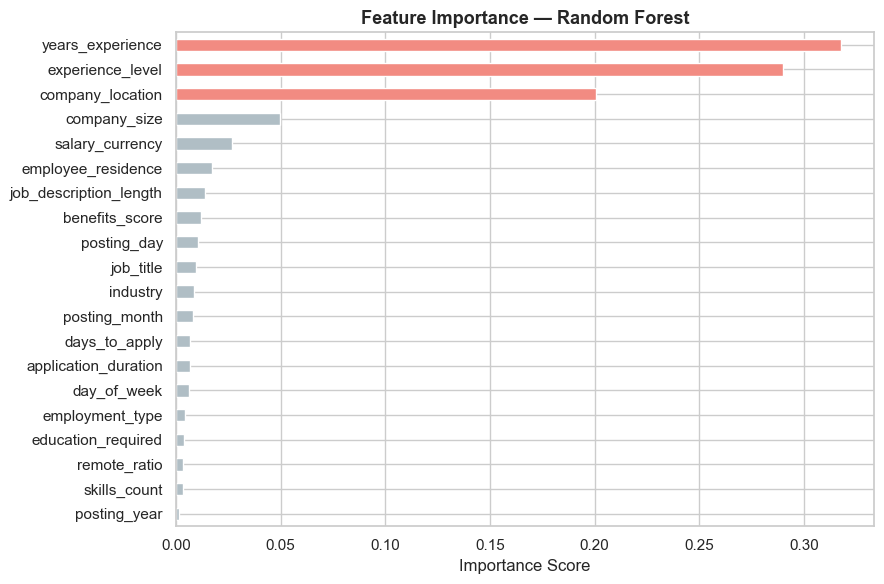

Top 5 most important features:
years_experience    0.317557
experience_level    0.289944
company_location    0.200507
company_size        0.049577
salary_currency     0.026852


In [32]:
plt.figure(figsize=(9, 6))
colors = ['#F28B82' if v > 0.15 else '#4A90D9' if v > 0.05 else '#B0BEC5' for v in feat_imp.values]
feat_imp.plot(kind='barh', color=colors)
plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(feat_imp.sort_values(ascending=False).head(5).to_string())

In [33]:
df

,job_title,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,education_required,years_experience,...,job_description_length,benefits_score,application_duration,posting_month,posting_year,posting_day,day_of_week,days_to_apply,skills_count,salary_usd
0,0.003399,-2.261256,-0.445200,0.573224,-0.181799,1.234367,0.516249,-1.206612,-0.441457,-0.762152,...,0.192669,-0.411952,1.695907,0.419900,-0.566700,0.366307,0.505220,1.695907,0.007951,96731
1,1.575214,0.505698,0.450725,-1.072690,1.494300,-1.216598,1.377205,-1.206612,0.452030,-0.218426,...,-0.393901,-0.826906,0.773265,1.848779,-0.566700,1.162463,0.005991,0.773265,-1.215304,75146
2,0.258288,0.505698,-1.341125,-0.866951,-0.477582,0.008885,0.478816,-1.206612,0.452030,-1.124635,...,-0.270321,1.524501,-1.129683,-1.008979,1.764601,1.276200,0.005991,-1.129683,1.231207,39309
3,0.555658,0.505698,0.450725,1.327601,-0.280393,1.234367,-0.120110,0.019516,-0.441457,-0.218426,...,0.328433,-1.449337,-0.668363,1.563003,-0.566700,0.366307,-0.992468,-0.668363,1.231207,83948
4,-0.718787,0.505698,1.346650,-0.866951,1.494300,0.008885,0.141921,-1.206612,-1.334944,1.956474,...,0.841899,0.210480,-0.783693,-0.723203,1.764601,0.934990,-1.491698,-0.783693,0.007951,135830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,0.343250,0.505698,0.450725,1.327601,-0.625473,-1.216598,-0.756469,1.245644,-1.334944,0.325299,...,1.400619,-1.656814,1.234586,0.134124,-0.566700,-0.316112,0.005991,1.234586,0.007951,83404
14996,-0.931194,0.505698,1.346650,-0.866951,-0.477582,0.008885,-0.943633,-1.206612,-1.334944,1.412749,...,1.689553,0.348798,0.369609,-1.294755,1.764601,-0.884794,-0.493239,0.369609,1.231207,165635
14997,-0.633824,0.505698,0.450725,1.327601,-0.280393,0.008885,-1.505126,-1.206612,1.345517,0.325299,...,-0.728089,-0.411952,-0.899023,0.705676,-0.566700,-0.884794,0.005991,-0.899023,0.007951,73042
14998,-0.931194,0.505698,-1.341125,-0.866951,-0.329690,-1.216598,0.965444,0.019516,1.345517,-0.943393,...,0.570371,-0.757747,-0.553032,-0.437428,1.764601,-0.429848,1.004450,-0.553032,1.231207,33117


---
# ✅ Sprint 2 Addition: Cross-Validation & Save Best Model
> After comparing all models, we confirm the best one with 5-fold CV and save it for Sprint 3.


In [34]:
from sklearn.model_selection import cross_val_score
import joblib, os

save_dir = '/Users/rezwanshehik/Downloads/'

# Cross-validate all 4 models (5-fold)
models_dict = {
    'Linear Regression'  : lr,
    'Decision Tree'      : dt,
    'Random Forest'      : rf,
    'Gradient Boosting'  : gb
}

print(f'{'Model':<25} {'CV Mean R²':>12} {'CV Std':>10}')
print('-' * 50)
cv_results = {}
for name, model in models_dict.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    cv_results[name] = scores.mean()
    print(f'{name:<25} {scores.mean():>12.4f} {scores.std():>10.4f}')

best_cv_name  = max(cv_results, key=cv_results.get)
best_cv_model = models_dict[best_cv_name]
print(f'\n🏆 Best model by CV: {best_cv_name}  (R² = {cv_results[best_cv_name]:.4f})')


Model                       CV Mean R²     CV Std
--------------------------------------------------
Linear Regression               0.6239     0.0049
Decision Tree                   0.7696     0.0105
Random Forest                   0.8728     0.0043
Gradient Boosting               0.8770     0.0019

🏆 Best model by CV: Gradient Boosting  (R² = 0.8770)


In [35]:
# Save the best model from Sprint 2
os.makedirs(save_dir, exist_ok=True)
joblib.dump(best_cv_model, save_dir + 'best_model_sprint2.joblib')
print(f'✅ Best model saved → {save_dir}best_model_sprint2.joblib')
print(f'   Model type : {type(best_cv_model).__name__}')


✅ Best model saved → /Users/rezwanshehik/Downloads/best_model_sprint2.joblib
   Model type : GradientBoostingRegressor


### Sprint 2 now saves:
| File | Purpose |
|------|--------|
| `best_model_sprint2.joblib` | Best model for Sprint 3 to tune further |
